# Artefact Reduction by Homogeneous Field Correction

This section explains how Homogeneous Field Correction (HFC) is used to attenuate artefacts in the OPM data [1]. HFC is a preprocessing technique that suppresses artefacts manifesting as spatially uniform (homogeneous) magnetic fields across the sensor array. These artefacts are generated by sources in the environment, such as electrical devices or moving magnetic objects — ventilation systems, elevators, passing cars, magnetic door latches, and vibrations. Another large contribution comes from movement of the sensor array within the residual field of the magnetically shielded room. Because these sources are typically far from the sensor array, the fields they produce are approximately spatially homogeneous. Brain activity, by contrast, produces less homogeneous fields with higher spatial gradients, because the neuronal sources are close to the sensors.

The goal of HFC is to remove the component of the measured signal that is common across all sensors, on the assumption that it arises from a spatially uniform field. Applying HFC improves the quality of the OPM data, reduces background noise, and makes the system more accurate in detecting and localising the true magnetic fields generated by brain activity.

HFC operates as a linear projection applied to all sensors. Sensors that are 'flat' or excessively noisy must be removed beforehand, so that they do not spread their noise across the array through the projection. Therefore, before applying HFC, it is important to identify and exclude 'bad' sensors.

## Import the necessary modules
Below are the required Python modules to be imported for this section

In [1]:
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids

## File overview

This section reads the BIDS-formatted recording produced in the previous section:
```
<BIDS_ROOT>/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_meg.fif
```
and writes the HFC-corrected data to the `derivatives` folder of the BIDS dataset:
```
<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
```

## Loading the BIDS data

Specify the parameters allowing for defining the BIDS folder `data_path` which is dependent on where the data are stored locally.  

In [2]:
subject = '01'  
session = '01'  
task = 'SpAtt'
run = '01'  
meg_suffix = 'meg'
meg_extension = '.fif'
events_suffix = 'eve'
events_extension = '.tsv'

#data_path='E:/Data/Cerca'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA'

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=meg_suffix, extension=meg_extension, root=bids_root)

Create a 'derivative folder' where the processed data will be stored:

In [3]:
deriv_root = op.join(bids_root, 'derivatives/preprocessing')  # output path

deriv_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix=meg_suffix, root=deriv_root).mkdir()

deriv_fname = bids_path.basename.replace('meg', 'hfc_raw') # output filename
deriv_file_1 = op.join(deriv_path.directory, deriv_fname)

Read the raw data

In [4]:
raw = read_raw_bids(bids_path=bids_path, verbose=False,extra_params={'preload':True})

## Identifying the faulty sensors

The first step is to flag sensors as "bad" based on observations made during acquisition. This list is then augmented by identifying outliers from the power spectral density (PSD) estimates. Here, the sensors B4 and H6 were noted as faulty during the recording.

In [5]:
ch_names = raw.info['ch_names']
bad_chs = ['B4', 'H6']

# Each physical sensor contributes three channels (X, Y, Z), so match by substring
bad_channels = [name for name in ch_names if any(ch in name for ch in bad_chs)]
raw.info['bads'] = bad_channels

# Print the bad channels
print("Bad channels marked:", raw.info['bads'])

Bad channels marked: ['T14 H6 Z', 'T14 H6 Y', 'T14 H6 X', 'AFz B4 Z', 'AFz B4 Y', 'AFz B4 X']


Now, additional noisy bad sensors will be identified based on the average power spectral density (PSD) of each sensor. Sensors with an average PSD value crossing a predefined threshold will be flagged as bad and hence  not contribute towards the HFC filtering. 

## Calculate and plot the PSDs

In [6]:
n_fft = 1500
picks = mne.pick_types(raw.info, meg=True,exclude='bads')
raw_PSD = raw.compute_psd(method="welch", fmin=0.1, fmax=120, picks=picks, n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2
average_power = np.mean(psd_db, axis=1)

Effective window size : 2.000 (s)


To plot the result using the commands 

Plotting power spectral density (dB=True).


/opt/miniconda3/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


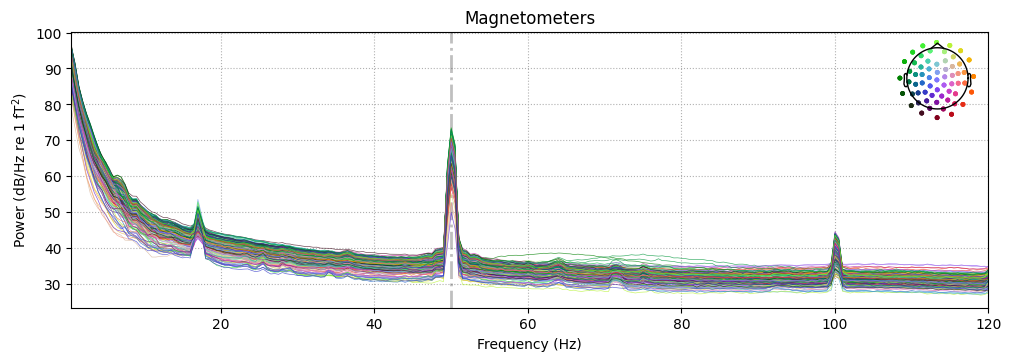

In [7]:
raw_PSD.plot();

### Histograms of sensor power

As a next step, we plot a histogram of the power averaged across frequencies for each sensor.

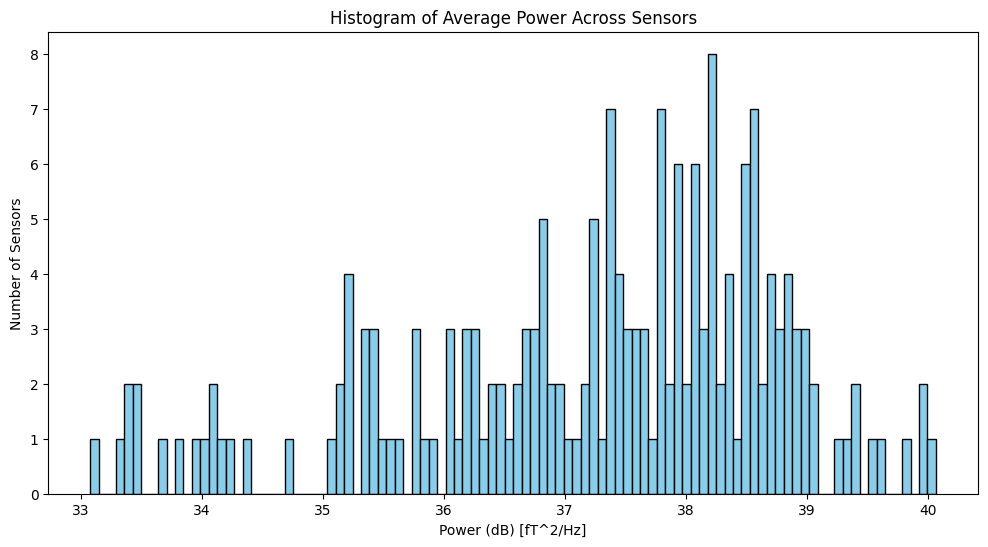

In [8]:
%matplotlib inline
plt.figure(figsize=(12, 6))
BNS = 100
plt.hist(average_power, bins=BNS,color='skyblue',edgecolor='black'); plt.xlabel('Power (dB) [fT^2/Hz]');plt.ylabel('Number of Sensors'); plt.title('Histogram of Average Power Across Sensors');

The power distributions look reasonable, as all sensors were in an excellent state during data collection. For illustration, we will reject sensors with a noise level above 39.1 dB. This threshold is admittedly somewhat arbitrary; the point is to demonstrate an example of automatic thresholding.

### Identifying and flagging sensors with high power

To identify the sensors above the threshold of 39.1 dB write

In [9]:
sensor_names = raw_PSD.ch_names
sensors_above_threshold = [sensor_names[i] for i, avg in enumerate(average_power) if avg > 39.1]
print(sensors_above_threshold)

['O9 G3 X', 'T1 C7 Z', 'T5 C5 Z', 'T5 C5 Y', 'T7 C8 Y', 'T11 G7 Y', 'F2 B7 Y', 'C8 F7 X', 'O2 H3 Y', 'O6 H1 Y']


Flag the sensors above the threshold as bad with the data structure. This will be done by augmenting the existing list of bad sensors

In [10]:
raw.info['bads'].extend(sensors_above_threshold)
print(raw.info['bads'])

['T14 H6 Z', 'T14 H6 Y', 'T14 H6 X', 'AFz B4 Z', 'AFz B4 Y', 'AFz B4 X', 'O9 G3 X', 'T1 C7 Z', 'T5 C5 Z', 'T5 C5 Y', 'T7 C8 Y', 'T11 G7 Y', 'F2 B7 Y', 'C8 F7 X', 'O2 H3 Y', 'O6 H1 Y']


**Question 1:** Where are the noisy sensors located? Identify and mark the sensor on the layout below:

**Question 2:** Plot the time course of a few noisy sensors and compare to non-noisy sensors. What characterizes the noisy sensors?

## Applying Homogenous Field Correction

Before doing HFC plot the PSD excluding the bad sensors. 

#### Plot of the raw data before pre-processing

For brevity, we will plot data from a subset of sensors, selecting every 5th sensor.

Text(0.5, 1.0, 'Before Applying HFC')

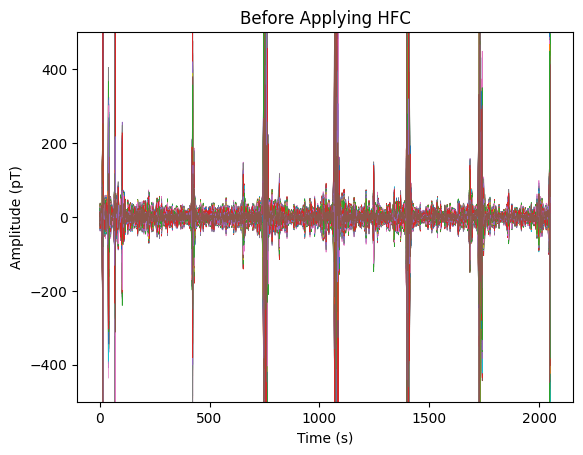

In [11]:
picks = mne.pick_types(raw.info, meg=True,exclude='bads')
rawRJ=raw.copy().pick(picks)

amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(rawRJ.times)-300
step = 500
data_ds, time_ds = rawRJ[:, :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-500, 500)
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
#plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("Before Applying HFC")

Note the large artefacts occurring roughly every ~300 s. They coincide with the breaks between blocks and are probably caused by head movements as the participant stretches and repositions.

### Interference rejection using Homogeneous Field Correction

In [12]:
rawHFC=rawRJ.copy()
projs = mne.preprocessing.compute_proj_hfc(rawHFC.info, order=2)
rawHFC.add_proj(projs).apply_proj(verbose="error")

8 projection items deactivated


<Raw | sub-01_ses-01_task-SpAtt_run-01_meg.fif, 176 x 1539808 (2053.1 s), ~2.02 GiB, data loaded>

Plotting the raw data after applying HFC

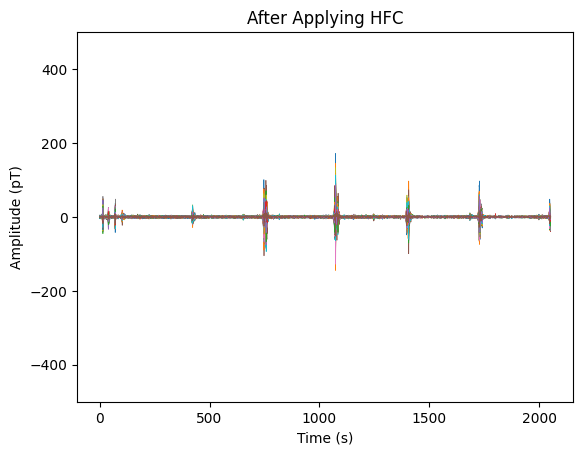

In [13]:
amp_scale = 1e12  # Converting to pico Tesla(pT)
stop = len(raw.times) - 300
step = 500
data_ds, time_ds = rawHFC[:, :stop]
data_ds, time_ds = data_ds[:, ::step]* amp_scale , time_ds[::step]

plt.plot(time_ds, data_ds.T - np.mean(data_ds, axis=1),lw=0.5);
plt.ylim(-500, 500);
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude (pT)')
#plt.xlim(time_ds[0], time_ds[-1])
#plt.grid(True)
plt.title("After Applying HFC")
plt.show()

The artefacts are now clearly reduced, demonstrating the utility of HFC. These artefacts were most likely caused by the participant moving within the room: despite the shielding, a residual field remains, and this produces a signal whenever the sensors move through it.

### Power spectra after HFC

Another way to inspect the effects of HFC is to consider the power-spectra

In [14]:
n_fft = 1500
raw_PSD = rawRJ.compute_psd(method="welch", fmin=0.1, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft/2))
psds = raw_PSD.get_data() # units are in T^2/Hz
freqs = raw_PSD.freqs 
psd_db = 10 * np.log10(psds * 1e30)# Ref power: 1fT^2=1e-30T^2

raw_PSDc = rawHFC.compute_psd(method="welch", fmin=0.1, fmax=120, picks='mag', n_fft=n_fft, n_overlap=int(n_fft/2))
psdsc = raw_PSDc.get_data() # units are in T^2/Hz
freqsc = raw_PSDc.freqs 
psd_dbc = 10 * np.log10(psdsc * 1e30)  # Ref power: 1fT^2=1e-30T^2           

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)


For comparison, plot the spectra next to each other for no HFC and for HFC: 

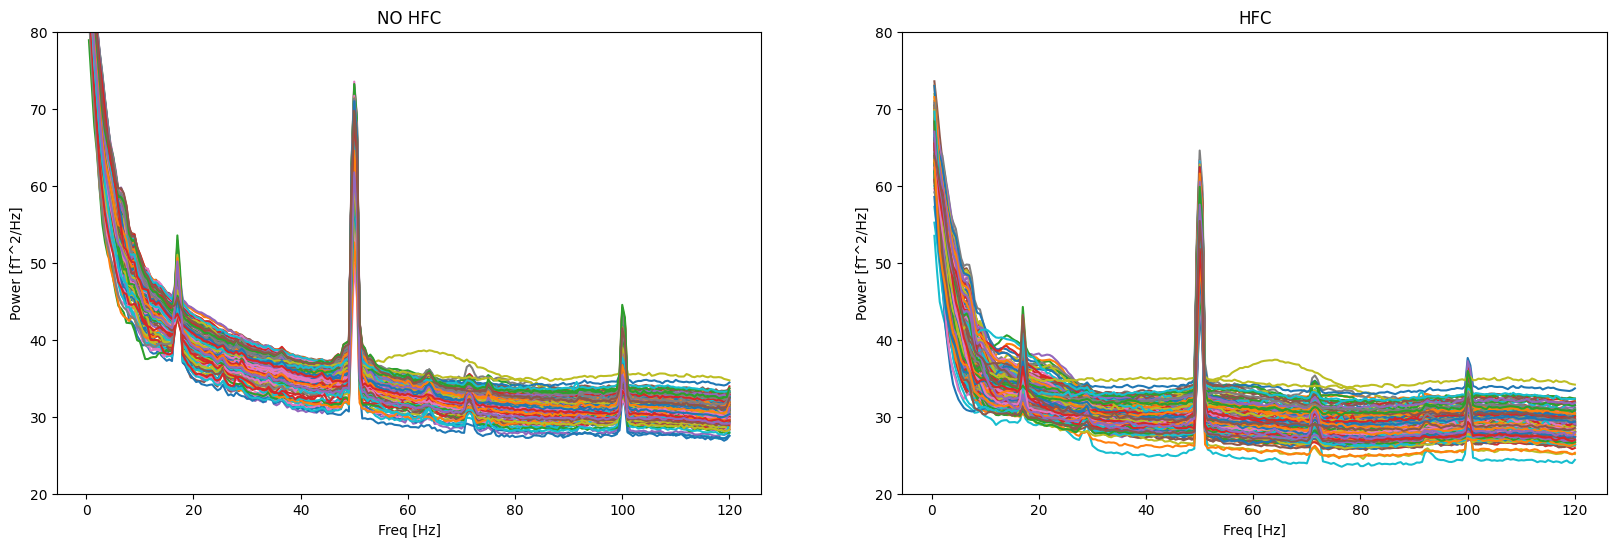

In [15]:
plt.figure(figsize=(20, 6))

plt.subplot(1,2,1)
plt.plot(freqs,psd_db.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('NO HFC');

plt.subplot(1,2,2)
plt.plot(freqsc,psd_dbc.T);plt.ylim(20, 80);plt.xlabel('Freq [Hz]');plt.ylabel('Power [fT^2/Hz]');plt.title('HFC');

The power over a wide frequency range is reduced following HFC. This becomes more evident when considering the spectra averaged over sensors:

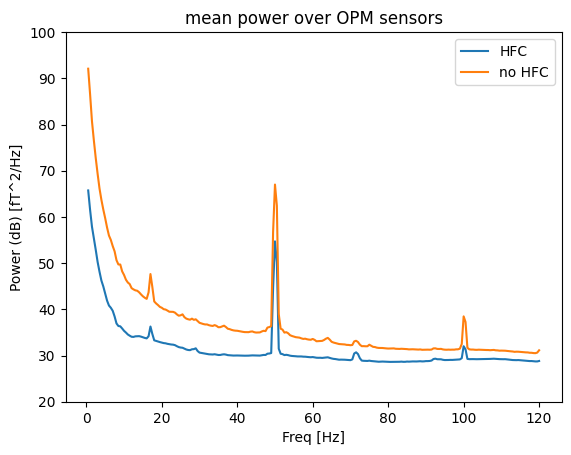

In [16]:
plt.plot(freqsc,np.mean(psd_dbc.T,axis=1), label='HFC')
plt.plot(freqs,np.mean(psd_db.T,axis=1),label='no HFC')
plt.legend();plt.ylim(20, 100);plt.xlabel('Freq [Hz]');
plt.ylabel('Power (dB) [fT^2/Hz]');plt.title('mean power over OPM sensors');

The reduction in power after HFC is now evident, particularly at the lower frequencies. This reflects the attenuation of artefacts, most likely those arising from head movements.

#### Store the filtered data within the derivatives folder of the BIDS directory.

### Sensor power by axis (X, Y, Z)

The sensor power will now be considered separately for the X, Y and Z axes. Separating the sensors by axis mainly facilitates the later interpretation of the data. The Z axis corresponds to the sensors that are most sensitive to the field perpendicular to the brain surface. The three sets of sensors are selected based on their channel-name suffixes:

In [17]:
OPMX = [item for item in rawHFC.ch_names if item.endswith("X")]
OPMY = [item for item in rawHFC.ch_names if item.endswith("Y")]
OPMZ = [item for item in rawHFC.ch_names if item.endswith("Z") and not item.startswith("BNC")]



Compute PSD for each X,Y and Z directions. This will be done using a time window of 1500 points resulting in a 0.5 Hz spectral resolution.


In [18]:
n_fft = 1500
raw_PSDX = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMX, n_fft=n_fft, n_overlap=int(n_fft/2))
raw_PSDY = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMY, n_fft=n_fft, n_overlap=int(n_fft/2))
raw_PSDZ = rawHFC.compute_psd(method="welch", fmin=5, fmax=120, picks=OPMZ, n_fft=n_fft, n_overlap=int(n_fft/2))


psdsX = raw_PSDX.get_data() # units are in T^2/Hz
freqsX = raw_PSDX.freqs 
psd_dbX = 10 * np.log10(psdsX * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerX = np.mean(psd_dbX, axis=1)

psdsY = raw_PSDY.get_data() # units are in T^2/Hz
freqsY = raw_PSDY.freqs 
psd_dbY = 10 * np.log10(psdsY * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerY = np.mean(psd_dbY, axis=1)

psdsZ = raw_PSDZ.get_data() # units are in T^2/Hz
freqsZ = raw_PSDZ.freqs 
psd_dbZ = 10 * np.log10(psdsZ * 1e30)  # Ref power: 1fT^2=1e-30T^2           
average_powerZ = np.mean(psd_dbZ, axis=1)

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)
Effective window size : 2.000 (s)




To plot the result using the commands


Text(0.5, 1.0, 'axis Z')

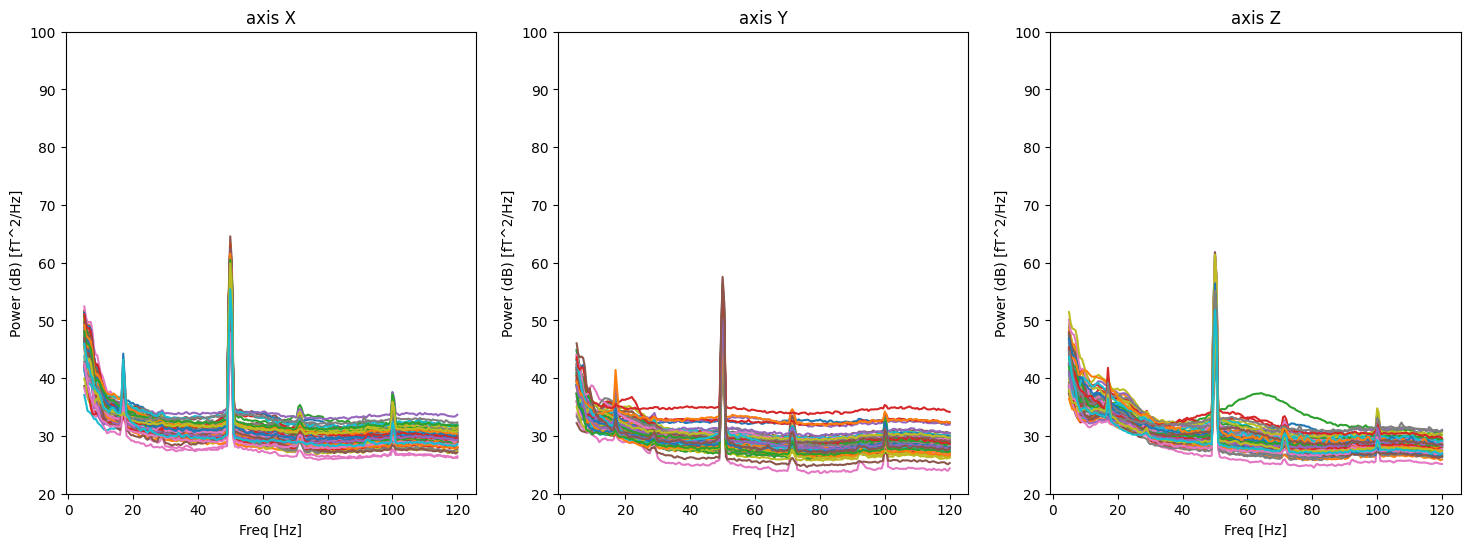

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(freqsX, psd_dbX.T); plt.ylim(20, 100); plt.xlabel('Freq [Hz]'); plt.ylabel('Power (dB) [fT^2/Hz]'); plt.title('axis X')

plt.subplot(1, 3, 2)
plt.plot(freqsY, psd_dbY.T); plt.ylim(20, 100); plt.xlabel('Freq [Hz]'); plt.ylabel('Power (dB) [fT^2/Hz]'); plt.title('axis Y')

plt.subplot(1, 3, 3)
plt.plot(freqsZ, psd_dbZ.T); plt.ylim(20, 100); plt.xlabel('Freq [Hz]'); plt.ylabel('Power (dB) [fT^2/Hz]'); plt.title('axis Z')

The spectra look reasonable, with no obvious outliers in the 0–50 Hz range. Notably, the Z-axis sensors also show the fewest stray outliers.

In [20]:
rawHFC.save(deriv_file_1, overwrite=True) 

Writing /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
Closing /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif
[done]


[PosixPath('/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjA/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_hfc_raw.fif')]

## Preregistration and Publication

A preregistration should describe the artefact-suppression pipeline in enough detail to be reproduced exactly. For the HFC stage we recommend committing to the following in advance:

**Bad-sensor identification**
- The criteria for marking sensors as bad: those noted during acquisition (here B4 and H6) and those flagged automatically.
- The automatic criterion, stated quantitatively: the metric (average PSD in dB), the frequency range used to compute it (here 0.1–120 Hz, Welch method, `n_fft = 1500`), and the rejection threshold (here 39.1 dB). State whether the threshold is fixed a priori or derived from the data (e.g. a fixed dB value vs. mean + *k*·SD), since a fixed value is only meaningful for a specific system and recording setup.
- Whether bad sensors are excluded from the HFC projection only, or dropped entirely.

**HFC parameters**
- The spherical-harmonic expansion `order` passed to `compute_proj_hfc` (here `order=2`), which determines how many spatial components are removed. Report it explicitly, as higher orders remove more interference but risk attenuating brain signal.
- That HFC is applied as a projection after excluding bad sensors.
- Software and versions (MNE-Python, MNE-BIDS), as defaults may change between releases.

**Verification and outputs**
- How the effect of HFC will be assessed (e.g. before/after time series and PSDs).
- Where the corrected data are stored (BIDS `derivatives/preprocessing`) and the output naming convention (`*_hfc_raw.fif`).

Distinguish choices fixed in advance (confirmatory) from any adjusted after inspecting the data (exploratory), and pre-specify any thresholds rather than tuning them post hoc.

**Example preregistration / methods text**

> "Prior to interference suppression, sensors identified as faulty during acquisition were marked as bad, and this list was augmented with sensors whose average power spectral density (0.1–120 Hz, Welch method) exceeded 39.1 dB. Homogeneous Field Correction (HFC) [1] was then applied as a linear projection (spherical-harmonic order 2), excluding the bad sensors. The effect of HFC was verified by comparing sensor time series and power spectra before and after correction. All processing was performed in MNE-Python (version X.X), and the corrected data were stored in the BIDS derivatives folder."

## References

[1] Tierney, T.M., Alexander, N., Mellor, S., Holmes, N., Seymour, R., O'Neill, G.C., Maguire, E.A., & Barnes, G.R. (2021) *Modelling optically pumped magnetometer interference in MEG as a spatially homogeneous magnetic field.* Neuroimage. 244:118484. https://doi.org/10.1016/j.neuroimage.2021.118484. 
